In [32]:
""" BLOCK 1 — Setup """
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as path_effects
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import statsmodels.api as sm
import statsmodels.formula.api as smf
import umap

# Set global font sizes and PDF compatibility
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', size=12)          # controls default text sizes
plt.rc('axes', labelsize=12)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=10)    # fontsize of the tick labels
plt.rc('ytick', labelsize=10)    # fontsize of the tick labels
plt.rc('legend', fontsize=10)    # legend fontsize

os.makedirs("../figures", exist_ok=True)

In [33]:
""" BLOCK 2 — Load & Aggregate Data to NATION Level """
df_raw = pd.read_csv("../data/WVS_Cross-National_Wave_7_csv_v6_0.csv", low_memory=False)
df = df_raw.groupby("B_COUNTRY").first().reset_index()

In [34]:
""" BLOCK 3 — THEORY: Objective Variable Selection """
order_vars = ["ruleoflaw", "btistate", "v2x_rule", "corrupttransp"]
liberty_vars = ["v2xcl_rol", "v2x_freexp_altinf", "v2x_frassoc_thick", "v2clrelig"]
equality_vars = ["v2pepwrses", "v2xeg_eqdr", "v2peapsecon", "v2peedueq", "v2pehealth"]
outcome_vars = ["hdi", "GDPpercap1"] 

cols = order_vars + liberty_vars + equality_vars + outcome_vars
data = df[cols].copy()

# Fix GDP strings (e.g. "50,000" -> 50000)
if data["GDPpercap1"].dtype == 'O':
    data["GDPpercap1"] = data["GDPpercap1"].str.replace(',', '').astype(float)

# Replace missing codes
data = data.replace([-5, -4, -3, -2, -1, -9999], np.nan)

In [35]:
""" BLOCK 4 — Data Rescue: KNN Imputation """
# Instead of dropping countries with 1 missing variable, we mathematically estimate it
imputer = KNNImputer(n_neighbors=5)
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns, index=df["B_COUNTRY"])

print("Rescued Macro shape (Countries):", data_imputed.shape)

Rescued Macro shape (Countries): (66, 15)


In [36]:
""" BLOCK 5 — Standardization (Updated names) """
features = order_vars + liberty_vars + equality_vars
scaler = StandardScaler()
scaled_features = pd.DataFrame(
    scaler.fit_transform(data_imputed[features]), 
    columns=features, 
    index=data_imputed.index
)

In [37]:
""" BLOCK 6 — THEORY: Construct Latent Axes (Updated names) """
X_theory = pd.DataFrame({
    "Order": scaled_features[order_vars].mean(axis=1),
    "Liberty": scaled_features[liberty_vars].mean(axis=1),
    "Equality": scaled_features[equality_vars].mean(axis=1)
}, index=data_imputed.index)

# Magnitude and Imbalance remain the same (Geometry logic)
X_theory["Magnitude"] = X_theory[["Order", "Liberty", "Equality"]].mean(axis=1)
X_theory["Imbalance"] = X_theory[["Order", "Liberty", "Equality"]].std(axis=1)

In [38]:
""" BLOCK 7 — DATA-DRIVEN: PCA on Raw Items """
pca_items = PCA(n_components=0.90)
X_items_pca = pca_items.fit_transform(scaled_features)
print("Components needed for 90% variance:", pca_items.n_components_)

Components needed for 90% variance: 5


In [39]:
""" BLOCK 8 — THEORY PCA (Geometry Check) """
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_theory[["Order", "Liberty", "Equality"]])
print("Explained variance (theory PCA):", pca.explained_variance_ratio_)

Explained variance (theory PCA): [0.8141977 0.1343774 0.0514249]


In [40]:
""" BLOCK 9 — Loadings (Renamed Columns) """
loadings = pd.DataFrame(
    pca.components_,
    columns=["Order", "Liberty", "Equality"],
    index=[f"PC{i+1}" for i in range(pca.n_components_)]
)
print("Theoretical Axis Loadings:\n", loadings)

Theoretical Axis Loadings:
         Order   Liberty  Equality
PC1  0.607225  0.546247  0.576967
PC2 -0.146828  0.790816 -0.594181
PC3  0.780845 -0.276087 -0.560408


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


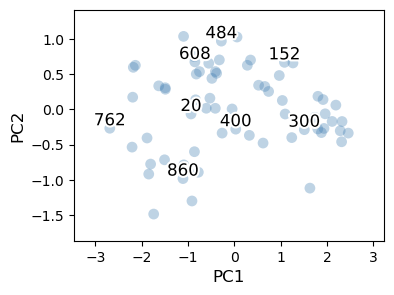

In [43]:
""" BLOCK 10 — H2: Manifold of State Governance (PCA) """
countries = data_imputed.index.values

plt.figure(figsize=(4, 3))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.35, s=60, c='steelblue', edgecolors='none')

for i, txt in enumerate(countries):
    if i % 9 == 0:
        t = plt.text(X_pca[i,0], X_pca[i,1], txt, fontsize=12, 
                     ha='center', va='bottom')
        t.set_path_effects([path_effects.withStroke(linewidth=3, foreground='white')])

plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.margins(0.15)

# Save figure
plt.savefig("../figures/fig1_pca_manifold.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig1_pca_manifold.eps", bbox_inches='tight')
plt.show()

/home/adriel/anaconda3/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


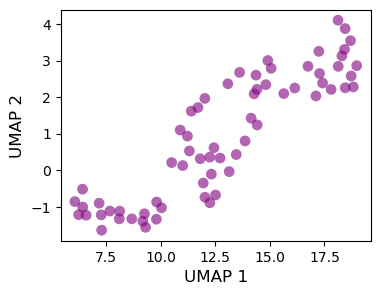

In [44]:
""" BLOCK 11 — H2: UMAP (Nonlinear Geometry) """
reducer = umap.UMAP(n_neighbors=8, min_dist=0.3, random_state=42)

X_umap = reducer.fit_transform(X_theory[["Order", "Liberty", "Equality"]])

plt.figure(figsize=(4, 3))
plt.scatter(X_umap[:,0], X_umap[:,1], alpha=0.6, s=60, c='purple', edgecolors='none')

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Save figure
plt.savefig("../figures/fig3_umap_projection.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig3_umap_projection.eps", bbox_inches='tight')
plt.show()

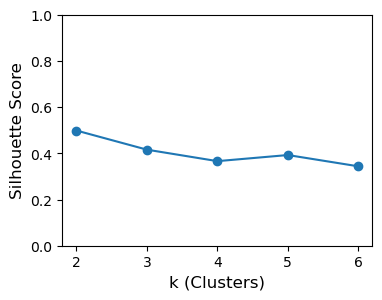

In [46]:
""" BLOCK 12 — H2: Clustering Test """
scores = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca, labels))

plt.figure(figsize=(4, 3))
plt.plot(range(2, 7), scores, marker='o')

plt.xlabel("k (Clusters)")
plt.ylabel("Silhouette Score")
plt.ylim(0, 1)

# Save figure
plt.savefig("../figures/fig4_silhouette_scores.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig4_silhouette_scores.eps", bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


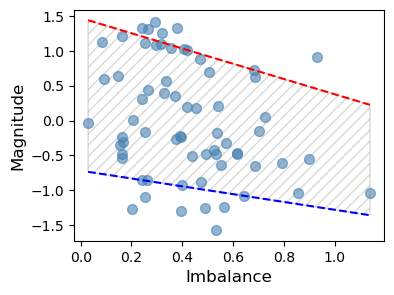

In [47]:
""" BLOCK 13 — H1: The Funnel of State Development (Quantile Constraints)"""
q_data = pd.DataFrame({'Imbalance': X_theory["Imbalance"], 'Magnitude': X_theory["Magnitude"]})
mod = smf.quantreg('Magnitude ~ Imbalance', q_data)
x_vals = np.linspace(q_data['Imbalance'].min(), q_data['Imbalance'].max(), 100)
df_pred = pd.DataFrame({'Imbalance': x_vals})
y_upper = mod.fit(q=0.90).predict(df_pred)
y_lower = mod.fit(q=0.10).predict(df_pred)

plt.figure(figsize=(4, 3))
plt.scatter(X_theory["Imbalance"], X_theory["Magnitude"], alpha=0.6, s=50, c='steelblue')
plt.plot(x_vals, y_upper, color='red', linestyle='--', linewidth=1.5)
plt.plot(x_vals, y_lower, color='blue', linestyle='--', linewidth=1.5)

plt.fill_between(x_vals, y_lower, y_upper, facecolor="none", edgecolor="gray", hatch='///', alpha=0.3)
plt.xlabel("Imbalance")
plt.ylabel("Magnitude")

# Save figure
plt.savefig("../figures/fig5_funnel_capacity.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig5_funnel_capacity.eps", bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


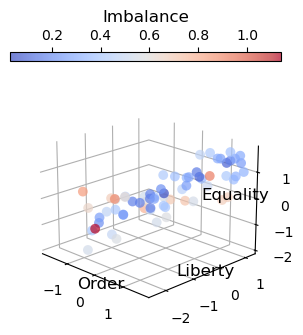

In [50]:
""" BLOCK 14 — H2: The 3D Institutional Manifold """
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection='3d')
ax.set_position([0.1, 0.1, 0.8, 0.7])

scatter = ax.scatter(X_theory['Order'], X_theory['Liberty'], X_theory['Equality'], 
                    c=X_theory['Imbalance'], cmap='coolwarm', s=50, alpha=0.7, edgecolors='none')

# Remove standard labels (set to empty strings)
ax.set_xlabel('', labelpad=0)
ax.set_ylabel('', labelpad=0)
ax.set_zlabel('', labelpad=0)

# Manually place labels
ax.text(0.1, -2.5, -2.6, "Order", color='black', fontsize=12, ha='center')
ax.text(1.4, 0, -2.6, "Liberty", color='black', fontsize=12, ha='center')
ax.text(2.5, -1.5, 1.4, "Equality", color='black', fontsize=12, va='center', rotation=90)

# Ticks spaced by 1
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.zaxis.set_major_locator(ticker.MultipleLocator(1))

# Clean up the cube panels
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('w')
ax.yaxis.pane.set_edgecolor('w')
ax.zaxis.pane.set_edgecolor('w')

ax.view_init(elev=20, azim=-45)
ax.dist = 11

# Place horizontal colorbar at the top
cb = plt.colorbar(scatter, ax=ax, orientation='horizontal', 
                    location='top', pad=0.08, shrink=0.7, aspect=30)
cb.set_label('Imbalance', fontsize=12, labelpad=5)
cb.ax.tick_params(labelsize=10)

# Save figure
plt.savefig("../figures/fig2_3d_manifold.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig2_3d_manifold.eps", bbox_inches='tight')
plt.show()

In [52]:
""" BLOCK 15 — OUTCOMES: Prepare Regression Data """
# Re-attach outcomes
df_model = pd.concat([X_theory, data_imputed[outcome_vars]], axis=1)

# Ensure no negative GDP for logging
df_model = df_model[df_model["GDPpercap1"] > 0]
y_hdi = df_model["hdi"]
y_gdp = np.log(df_model["GDPpercap1"])

# We test our geometry directly against the outcomes to avoid multicollinearity
X_outcomes = sm.add_constant(df_model[["Magnitude", "Imbalance"]])

In [53]:
""" BLOCK 16 — H4: Predicting Human Development (HDI) """
model_hdi = sm.OLS(y_hdi, X_outcomes).fit()
print("\n--- Predictors of Human Development Index (HDI) ---")
print(model_hdi.summary())


--- Predictors of Human Development Index (HDI) ---
                            OLS Regression Results                            
Dep. Variable:                    hdi   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     67.77
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           5.18e-16
Time:                        15:56:03   Log-Likelihood:                 83.285
No. Observations:                  62   AIC:                            -160.6
Df Residuals:                      59   BIC:                            -154.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [55]:
""" BLOCK 17 — H3 & H4: Predicting Economic Prosperity (Log GDP) """
# Note: df_model already has filtered GDP > 0 from Block 15
y_gdp = np.log(df_model["GDPpercap1"].astype(float))

# Predict using the geometric coordinates
X_outcomes = sm.add_constant(df_model[["Magnitude", "Imbalance"]].astype(float))
model_gdp = sm.OLS(y_gdp, X_outcomes).fit()

print("\n--- Predictors of Economic Prosperity (Log GDP) ---")
print(model_gdp.summary())

# Quick geometric interpretation printout
print("\nGeometric Interpretation:")
print(f"H3 Baseline Check: A 1-unit increase in Magnitude changes Log GDP by {model_gdp.params['Magnitude']:.3f}")
print(f"H4 Penalty Check: A 1-unit increase in Imbalance changes Log GDP by {model_gdp.params['Imbalance']:.3f}")


--- Predictors of Economic Prosperity (Log GDP) ---
                            OLS Regression Results                            
Dep. Variable:             GDPpercap1   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.647
Method:                 Least Squares   F-statistic:                     56.85
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.74e-14
Time:                        15:56:14   Log-Likelihood:                -47.762
No. Observations:                  62   AIC:                             101.5
Df Residuals:                      59   BIC:                             107.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


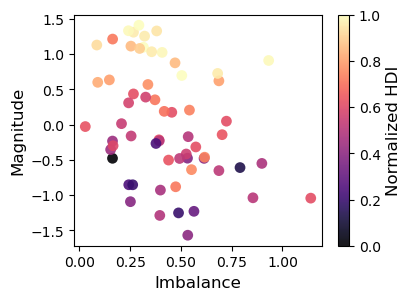

In [56]:
""" BLOCK 18 — Centerpiece Figure: The Geography of HDI """
outcome_norm = (y_hdi - y_hdi.min()) / (y_hdi.max() - y_hdi.min())
plt.figure(figsize=(4, 3))
scatter = plt.scatter(df_model["Imbalance"], df_model["Magnitude"], 
                    c=outcome_norm, cmap='magma', alpha=0.9, s=60, edgecolors='none')
cb = plt.colorbar(scatter)
cb.set_label("Normalized HDI")
plt.xlabel("Imbalance")
plt.ylabel("Magnitude")

# Save figure
plt.savefig("../figures/fig7_hdi_map.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig7_hdi_map.eps", bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


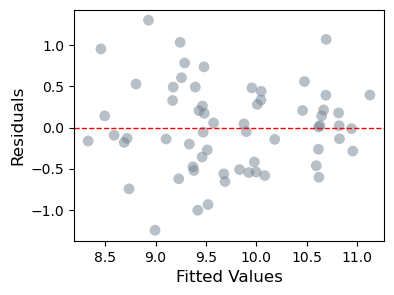

In [58]:
""" BLOCK 19 — OLS Assumption Check """
plt.figure(figsize=(4, 3))

plt.scatter(model_gdp.fittedvalues, model_gdp.resid, alpha=0.5, s=60, edgecolors='none',
            c='slategrey', linewidth=0.5)

# The Zero Line: Red, dashed, slightly thinner for a sharp look
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.xlabel("Fitted Values", fontsize=12)
plt.ylabel("Residuals", fontsize=12)

# Standard tick cleanup
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Save figure
plt.savefig("../figures/fig6_residuals.png", dpi=300, bbox_inches='tight')
plt.savefig("../figures/fig6_residuals.eps", bbox_inches='tight')
plt.show()